# Chapter 1: The Python Scientific Ecosystem

*Part I — Python for Data Science*


## Learning Objectives

By the end of this chapter you will be able to:

- Set up a reproducible development environment (conda/mamba, VS Code, Jupyter)
- Understand the role of each core library: NumPy, Pandas, Matplotlib, GeoPandas
- Manage packages and environments for reproducible science


```{note}
Keep tool installation instructions in a collapsible admonition block.
```


In [ ]:
# Standard imports — add chapter-specific imports below
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## From Click to Script: A New Perspective

You are likely accustomed to using word processors, spreadsheets, and GIS software. You might believe it is always easier to click a button than to write code. We usually refer to code used for automating a task as a script; therefore, we will use this term to clarify that this is not a book about software engineering. This is a book for non-programmers who realize the importance of Python in spatial data science.

Imagine you are working with a spreadsheet that includes country names, continents, population, and GDP (Gross Domestic Product). As showed in the figure below.

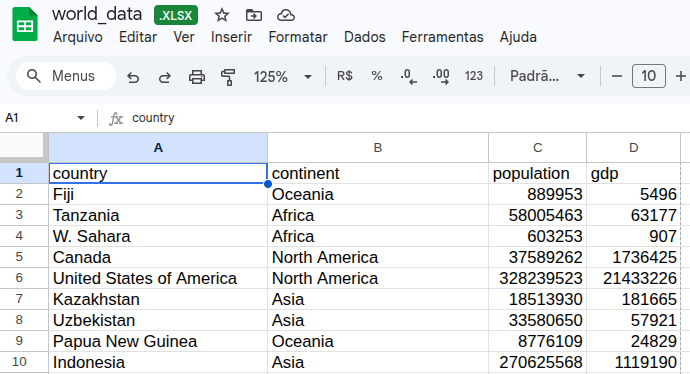

Suppose you need to calculate the total population and the world's GDP. How many clicks would that take? 

- Step 1: Click on the spreadsheet file to open it in a program such as Excel or LibreOffice Calc.
- Step 2: Click on an empty cell and type the '=' symbol, followed by the SUM function.
- Step 3: Click and drag to select the entire column of data, from the very first row to the bottom. It will be necessary to scroll through hundreds of rows, for example, ranging from A1 to A1000.
- Step 4: Type the closing parenthesis and press Enter.

Then, repeat the entire process for the GDP column.

All of these steps and clicks can be replaced by the code below.

In [ ]:
import geopandas as gpd

# The URL for the Natural Earth dataset
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"

# Loading the data with specific columns
world = gpd.read_file(url, columns=['NAME', 'CONTINENT', 'POP_EST', 'GDP_MD', 'geometry'])

# Calculating and printing the total population instantly
print (world.POP_EST.sum())

np.float64(7654092021.3)

Then, simply type the following line to calculate the total world GDP:

In [ ]:
print (world.GDP_MD.sum())

87344872


Now that we have loaded the spatial data using GeoPandas, I will give you a sneak peek at what Python can do:

<Axes: >

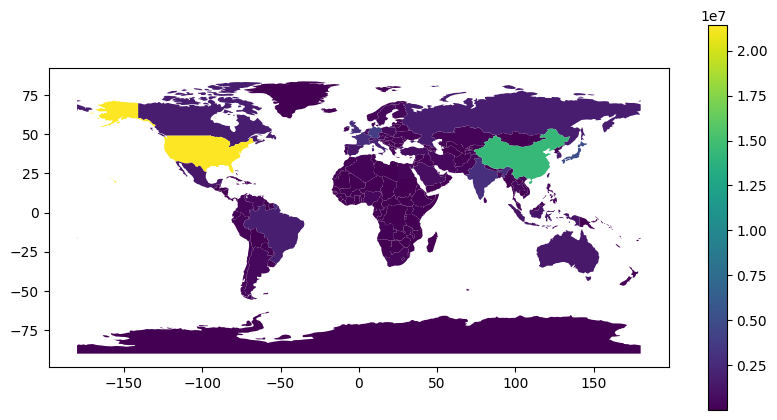

In [ ]:
world.plot(column='GDP_MD', legend=True, figsize=(10, 5))

We can easily repeat the process for the population data:

<Axes: >

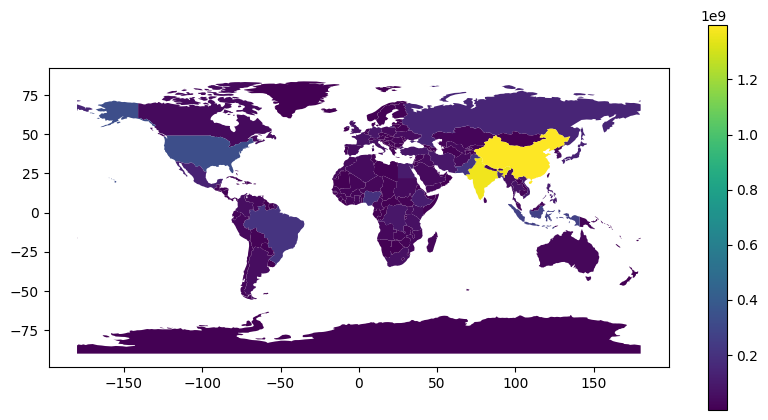

In [26]:
# Now, let's visualize population instead of GDP
world.plot(column='POP_EST', legend=True, figsize=(10, 5))

<div class="admonition info">
<p class="admonition-title">Keep in mind</p>
<p>Don't worry if you didn't understand everything yet; we will cover each detail throughout the book.</p>
</div>

Given that we have a continent column, how can I calculate the total population per continent and create a bar chart? It is easy to imagine that this would require many clicks in a spreadsheet program, but in Python, we only need one line of code, as shown below.

<Axes: title={'center': 'Population by Continent'}, xlabel='CONTINENT'>

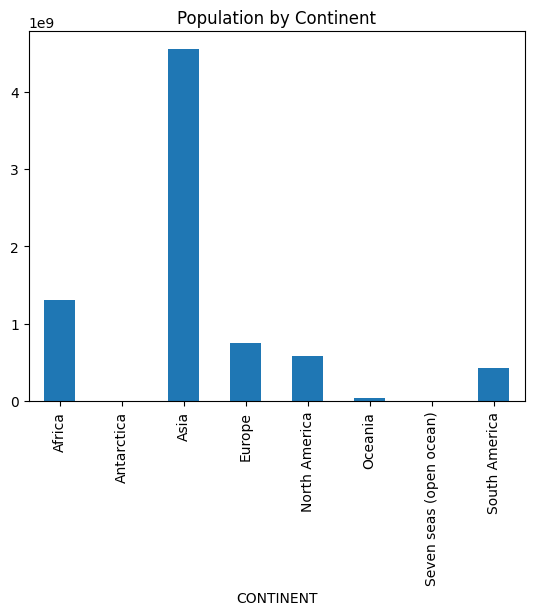

In [29]:
# Group by continent, sum the population, and plot a bar chart—all in one go!
world.groupby('CONTINENT')['POP_EST'].sum().plot(kind='bar', title='Population by Continent')

Then, we just add one more line for the GDP:

<Axes: title={'center': 'Population by Continent'}, xlabel='CONTINENT'>

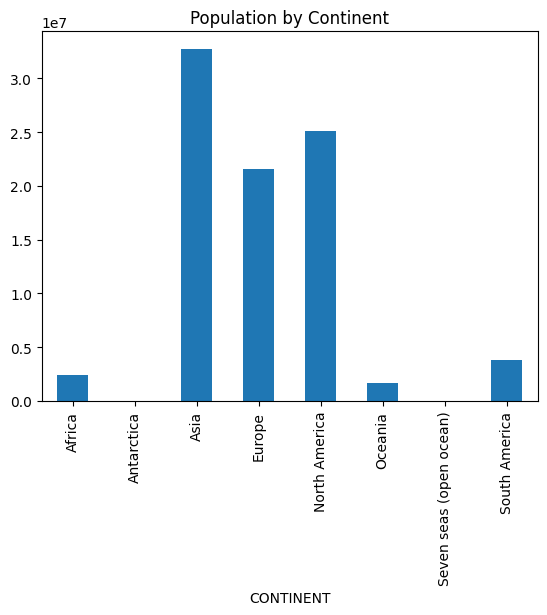

In [ ]:
world.groupby('CONTINENT')['GDP_MD'].sum().plot(kind='bar', title='GDP by Continent')

<div class="admonition todo">
<p class="admonition-title">It's up to you!</p>
<p>Using your preferred spreadsheet program, download the dataset and create bar charts for both population and GDP.</p>
</div>

You likely already know that computers are the best tool for automating repetitive tasks, but I hope you will soon realize that this is best achieved by writing scripts. Therefore, we need a different mindset—one that many authors refer to as 'computational thinking'. Computational Thinking is the thought processes involved in formulating a problem and its solution(s) so that the solutions are represented in a form that can be effectively carried out by an information-processing agent.


<div class="admonition quote">
<p class="admonition-title">Computational Thinking</p>
<p>"Computational thinking is a fundamental skill for everyone, not just for computer scientists." — Jeannette Wing (2006)</p>
</div>

Computational thinking helps solve problems across different disciplines and is incredibly valuable for data scientists. It is built upon four main pillars: decomposition, pattern recognition, abstraction, and algorithmic thinking.

1. Decomposition: Breaking down a complex problem into smaller, manageable parts.
2. Pattern Recognition: Identifying trends or similarities within or among problems.
3. Abstraction: Focusing on the important information only, ignoring irrelevant details.
4. Algorithmic Thinking: Developing a step-by-step solution to the problem.

To see these pillars in action, let's look at a practical problem: Calculating the percentage of the world's GDP contributed by each country.

### Decomposition

Instead of trying to solve the whole problem at once, we divide it into smaller, manageable tasks:

1. Calculate the total world GDP by summing the values for all countries.
2. For each specific country, divide its individual GDP by the total world GDP.
3. Multiply the result by 100 to get the percentage.

### Pattern Recognition

We notice a recurring pattern: the calculation for one country is identical to the calculation for any other. We can apply a single expression to all rows:

$$
\text{GDP Percentage} = \left( \frac{\text{Country GDP}}{\text{Total World GDP}} \right) \times 100
$$

### Abstraction

Abstraction refers to filtering out unnecessary details to focus on the essential attributes of a system. In our case, it means treating a complex nation simply as a GDP value. Through abstraction, we realize that we are not just looking at countries and economies; we are dealing with a standard percentage calculation. This allows us to use existing tools and functions in Python that were designed for this exact purpose.

### Algorithms 

<div class="admonition quote">
<p class="admonition-title">What is an Algorithm?</p>
<p>
  "An algorithm is a finite method, written in a fixed vocabulary, governed by precise instructions, moving in discrete steps, 1, 2, 3, ..., whose execution requires no insight, cleverness, intuition, intelligence, or perspicuity, and that sooner or later comes to an end."
</p>
<p style="text-align: right;">— <strong>David Berlinski</strong> (2000)</p>
</div>

This definition captures a crucial characteristic: the intelligence lies in the construction of the algorithm, not in its execution. The algorithm is a way to represent and share knowledge about a specific problem so that it can be executed by a computer and understood by anyone who speaks the language. A computer can execute the algorithm, and any person familiar with the language can understand it.

The following section presents, at a high level, the steps to calculate the percentage of the total GDP for each country. We will show how these steps are translated into the Python programming language using the Pandas library. Don’t worry about the technical details of the code yet; focus on the algorithmic concept. Notice how we can perform all these operations with just a few lines of code.

**Step 1: Load the input data**

In [31]:
# Using the Natural Earth dataset we loaded earlier
import geopandas as gpd
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

**Step 2: Calculate the total world GDP**

In [32]:
total_gdp = world['GDP_MD'].sum()

**Step 3: Calculate the GDP percentage for each country**

In [33]:
world['GDP_Share'] = (world['GDP_MD'] / total_gdp) * 100

**Step 4: Display the results**

In [34]:
world.set_index("NAME")['GDP_Share'].sort_values(ascending=False)

NAME
United States of America    24.538620
China                       16.421002
Japan                        5.818051
Germany                      4.420549
India                        3.284599
                              ...    
Vanuatu                      0.001069
W. Sahara                    0.001038
Antarctica                   0.001028
Falkland Is.                 0.000323
Fr. S. Antarctic Lands       0.000018
Name: GDP_Share, Length: 177, dtype: float64

By looking at these four steps, we can see Berlinski’s definition in action. The intelligence of this process lies in the construction of the algorithm—the logical sequence we designed—rather than in its execution. Once the instructions are written in the fixed vocabulary of Python and Pandas, the computer simply follows them to reach the final result. In this sense, an algorithm is a way to represent and share our knowledge about a problem in a format that both humans and machines can understand.

<div class="admonition success">
<p class="admonition-title">The Intelligence is Yours</p>
<p>
  As Berlinski noted, the execution of an algorithm requires no "insight" or "cleverness" from the computer. The true intelligence belongs to <strong>you</strong>, the author. By breaking the problem down and writing these steps, you have transformed your knowledge into a reusable tool that any computer can run.
</p>
</div>

## Setting Up Your Geospatial Lab

### The Foundations: Python and the Jupyter Philosophy

"Python is a high-level, interpreted, and general-purpose programming language. Created by Guido van Rossum and first released in 1991, Python **is renowned for** its clear and readable syntax, which simplifies both learning and writing code (LUTZ, 2013). Its design philosophy emphasizes code legibility, allowing programmers to express concepts in fewer lines of code compared to languages like C++ or Java."



<div class="admonition info">
<p class="admonition-title">Did you know?</p>
<p>The name "Python" isn't actually about the snake! It’s a tribute to the British comedy group *Monty Python's Flying Circus*. Guido van Rossum is a big fan of their 1970s BBC show.</p>
</div>

**Jupyter and Literate Programming**

"While software developers often use IDEs (Integrated Development Environments), many data analysts prefer **Jupyter Notebooks**. This is an interactive computing environment that allows users to create and share documents containing live code, visualizations, and narrative text.

Jupyter Notebooks promote the concept of **Literate Programming**, a paradigm introduced by Donald Knuth in 1984. The core idea is that a program should be written to be understandable by both humans and computers. By integrating code with documentation and explanations in a narrative format, Literate Programming makes code more accessible, transparent, and reproducible."

To help you get started, I have organized this chapter into three distinct paths. If you want to start coding immediately without installing anything, the Cloud Path is for you. If you prefer to work on your own machine, the Local Path offers two choices: a user-friendly visual installer (Anaconda) or a professional setup using the Terminal. No matter which path you choose, the end result will be the same: a powerful environment ready to process geospatial data. Select the one that best fits your current needs; you can always explore the others later.

### The Cloud Path: Google Colab 

(The "Fast Track")

Google Colab is the quickest path to get up and running. It runs entirely in your browser and comes with most essential libraries pre-installed.

To get started, simply visit colab.research.google.com and log in with your Google account.


### The Local Path: Professional Environments 
(This is your split section where you provide the two options for their own computer)

#### The Guided Experience (Anaconda)
Best for: Windows users and those who prefer a visual interface (GUI)

#### The Developer’s Choice (Terminal & Virtual Environments) 
Best for: Linux/macOS users and those seeking total control over their setup.


In [28]:
# Code for section: Setting Up Your Environment
print (10)

10


## Package Management with conda and pip

*TODO: write content.*


In [ ]:
# Code for section: Package Management with conda and pip


## Core Libraries at a Glance

*TODO: write content.*


In [ ]:
# Code for section: Core Libraries at a Glance


## Jupyter Notebooks and VS Code

*TODO: write content.*


In [ ]:
# Code for section: Jupyter Notebooks and VS Code


## Summary and Further Reading

*TODO: write content.*


In [ ]:
# Code for section: Summary and Further Reading


## Summary

*TODO: summarise key takeaways.*

### Key concepts introduced

- TODO
- TODO
- TODO


## Further Reading

- *TODO: add references.*
